In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option(
    "display.max_colwidth", 12,
    "display.max_rows", 20,
    "display.max_columns", 50,
    "display.precision", 4
)
plt.style.use('../utils/MyStyle.txt')
cm = 1/2.54
palette = ["#3F3517",  '#CE2E31', '#C96F6B', '#CCA464', '#F8D768', '#F0DCD4']

### Pipeline prompts (3 Agents, 3 Supervisors)
- aspect term extraction (ATE), which identifies the features or aspects being discussed (e.g., "food"), 
- opinion term extraction (OTE), which finds the words expressing an opinion (e.g., "delicious"), 
- aspect-level sentiment classification (ASC)

In [2]:
import pandas as pd
import dspy
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from concurrent.futures import ThreadPoolExecutor, as_completed

from tqdm.auto import tqdm
tqdm.pandas()

import sys
sys.path.append("../utils")

# import graph_1
from graph_1_contex_new import *
from graph_1_graph_new import *
from graph_1_reducers import *

c:\Users\asus\miniconda3\envs\absa_val\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
graph = StateGraph(ABSAState)

graph.add_node("agent_initiation", node_initiation)
graph.add_node("ATE", node_ate)
graph.add_node("ATE_supervision", node_ate_supervision)

graph.add_edge("agent_initiation", "ATE")
graph.add_edge("ATE", "ATE_supervision")

graph.add_node("OTE", node_ote)
graph.add_node("OTE_supervision", node_ote_supervision)

graph.add_conditional_edges(
    "ATE_supervision",  
    should_continue_ate, 
    {
        "ATE": "ATE",  
        "OTE": "OTE"         
    })
graph.add_edge("OTE", "OTE_supervision")

graph.add_node("ALSC", node_alsc)
graph.add_node("ALSC_supervision", node_alsc_supervision)

graph.add_conditional_edges(
    "OTE_supervision",     
    should_continue_ote, 
    {
        "OTE": "OTE",  
        "ALSC": "ALSC"          
    })
graph.add_edge("ALSC", "ALSC_supervision")


graph.add_conditional_edges(
    "ALSC_supervision",    
    should_continue_alsc, 
    {
        "ALSC": "ALSC",
        "END": END
    })


graph.set_entry_point("agent_initiation")

app = graph.compile(checkpointer=MemorySaver())

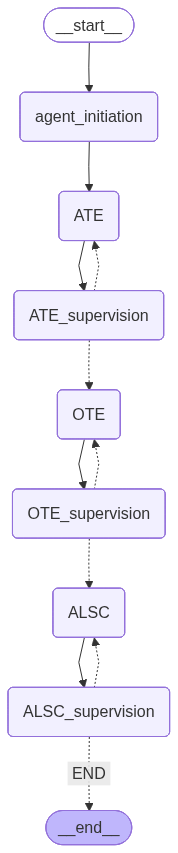

In [3]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
def run_absa_for_review(review_text: str, review_id: int):
    """Run your ABSA LangGraph pipeline on a single review."""
    try:
        # Create the initial state dynamically for each review
        state = ABSAState(
            review = review_text,
            review_id = review_id,

            aspects = [],
            aspects_decision = "",
            aspects_rationale = "",
            aspects_counter = 0,

            opinions = [],
            opinions_decision = "",
            opinions_rationale = "",
            opinions_counter = 0,

            sentiments = [],
            sentiments_decision = "",
            sentiments_rationale = "",
            sentiments_counter = 0,
        )

        result = app.invoke(state, {"recursion_limit": 100, "thread_id":review_id})

        return {
            "aspects": result.get("aspects", []),
            "aspects_decision": result.get("aspects_decision", ""),
            "opinions": result.get("opinions", []),
            "opinions_decision": result.get("opinions_decision", ""),
            "sentiments": result.get("sentiments", []),
            "sentiments_decision": result.get("sentiments_decision", ""),
        }

    except Exception as e:
        print(f"Error for review: {review_text[:25]}... -> {e}")
        return {
            "aspects": [],
            "aspects_decision": "",
            "opinions": [],
            "opinions_decision": "",
            "sentiments": [],
            "sentiments_decision": "",
        }


def run_absa_row(row):
    return row["ind"], run_absa_for_review(row["text"], int(row["ind"]))

In [6]:
df = pd.read_excel('../data/1000_annotated_sample_final.xlsx')
df = df.drop(columns=(['Unnamed: 0', 'flag']))
df['ind'] = df.index.astype(int)
df.shape

(1000, 13)

In [7]:
df.head(1)

,place_id,author,rating,date,text,place_name,index,date_parsed,ABSA_manual,atepc_json,len_manual,len_atepc,ind
0,ChIJs_LE-WM71moR_c251OO23DM,Edward Russel,1,3 years ago,"Utterly useless team, overpromises and underde...",Crave Cafe & Restaurant,2720,2022-10-11,"{""overall_sentiment"":""negative"",""aspects"":[{""a...","{'sentence': ""Utterly useless team , overpromi...",1,1,0


In [8]:
# res = run_absa_for_review(review_text=df.loc[1, 'text'], review_id=int(df.loc[1, 'ind']))

In [9]:
# res

In [10]:
results = {}

with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {
        executor.submit(run_absa_row, row): idx
        for idx, row in df.iterrows()
    }

    for future in tqdm(as_completed(futures), total=len(futures), desc="Running ABSA in parallel"):
        ind, res = future.result()
        results[ind] = res

# Convert dict of results back into alignment with df
df["absa_results"] = df["ind"].map(results)
df["sentiments"] = df["absa_results"].apply(lambda x: x["sentiments"])

Running ABSA in parallel: 100%|██████████| 1000/1000 [1:01:41<00:00,  3.70s/it]


In [11]:
# df["absa_results"] = df.progress_apply(func= lambda row: run_absa_for_review(review_text=row["text"], review_id=row["ind"]),
#                                         axis=1)

# # Optionally extract nested parts into their own columns
# # df["aspects"] = df["absa_results"].apply(lambda x: x["aspects"])
# # df["opinions"] = df["absa_results"].apply(lambda x: x["opinions"])
# df["sentiments"] = df["absa_results"].apply(lambda x: x["sentiments"])

In [12]:
df.to_excel('1000_annotated_sample_final_graph_1_v2.xlsx')

### 3 Steps, 1 Supervisor
Try to do the absa using a single prompt

In [4]:
import pandas as pd
import dspy
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from concurrent.futures import ThreadPoolExecutor, as_completed

from tqdm.auto import tqdm
tqdm.pandas()

import sys
sys.path.append("../utils")

# import graph_1
from graph_2_contex_new import *
from graph_2_graph_new import *

In [5]:
graph = StateGraph(ABSAState)

graph.add_node("agent_initiation", node_initiation)
graph.add_node("ATE", node_ate)
graph.add_node("OTE", node_ote)
graph.add_node("ALSC", node_alsc)
graph.add_node("Supervision", node_supervision)

graph.add_edge("agent_initiation", "ATE")
graph.add_edge("ATE", "OTE")
graph.add_edge("OTE", "ALSC")
graph.add_edge("ALSC", "Supervision")

graph.add_conditional_edges(
    "Supervision",    # Source node
    should_continue_absa, # Action
    {
        "ATE": "ATE",
        "OTE": "OTE", 
        "ALSC": "ALSC",   
        "END": END        
    })


graph.set_entry_point("agent_initiation")

app = graph.compile(checkpointer=MemorySaver())

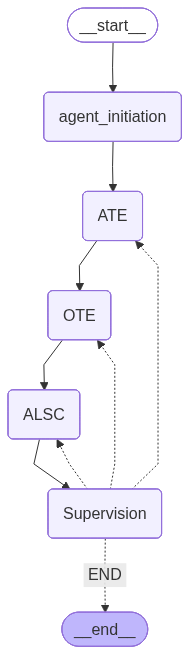

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
def run_absa_for_review(review_text: str, review_id: int):
    """Run your ABSA LangGraph pipeline on a single review."""
    try:
        # Create the initial state dynamically for each review
        state = ABSAState(
            review = review_text,
            review_id = review_id,

            aspects = [],
            aspects_decision = "",
            aspects_rationale = "",
            aspects_counter = 0,

            opinions = [],
            opinions_decision = "",
            opinions_rationale = "",
            opinions_counter = 0,

            sentiments = [],
            sentiments_decision = "",
            sentiments_rationale = "",
            sentiments_counter = 0,
        )

        # Run the graph
        result = app.invoke(state, {"recursion_limit": 100, "thread_id":review_id})

        # Extract only the relevant outputs
        return {
            "aspects": result.get("aspects", []),
            "aspects_decision": result.get("aspects_decision", ""),
            "opinions": result.get("opinions", []),
            "opinions_decision": result.get("opinions_decision", ""),
            "sentiments": result.get("sentiments", []),
            "sentiments_decision": result.get("sentiments_decision", ""),
        }

    except Exception as e:
        print(f"Error for review: {review_text[:25]}... -> {e}")
        return {
            "aspects": [],
            "aspects_decision": "",
            "opinions": [],
            "opinions_decision": "",
            "sentiments": [],
            "sentiments_decision": "",
        }

def run_absa_row(row):
    return row["ind"], run_absa_for_review(row["text"], int(row["ind"]))

In [8]:
df2 = pd.read_excel('../data/1000_annotated_sample_final.xlsx')
df2 = df2.drop(columns=(['Unnamed: 0', 'flag']))
df2['ind'] = df2.index.astype(int)
df2.shape

(1000, 16)

In [9]:
# res2 = run_absa_for_review(review_text=df2.loc[1, 'text'], review_id=int(df2.loc[1, 'ind']))

In [10]:
# res2

In [11]:
results = {}

with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {
        executor.submit(run_absa_row, row): idx
        for idx, row in df2.iterrows()
    }

    for future in tqdm(as_completed(futures), total=len(futures), desc="Running ABSA in parallel"):
        ind, res = future.result()
        results[ind] = res

df2["absa_results"] = df2["ind"].map(results)
df2["sentiments"] = df2["absa_results"].apply(lambda x: x["sentiments"])

Running ABSA in parallel:  95%|█████████▍| 946/1000 [28:51<04:59,  5.55s/it]2025/11/16 10:42:43 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.
2025/11/16 10:42:44 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.
2025/11/16 10:42:45 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.
2025/11/16 10:42:45 WARNING dspy.adapters.json_adapter: Failed to use structured output format, falling back to JSON mode.
Running ABSA in parallel:  95%|█████████▍| 948/1000 [29:08<05:26,  6.27s/it]

Error for review: Reasonable fully enclosed... -> litellm.RateLimitError: RateLimitError: XaiException - {"code":"Some resource has been exhausted","error":"Your team f12f289e-fb9c-4b88-82a4-ebba7e47fc18 has either used all available credits or reached its monthly spending limit. To continue making API requests, please purchase more credits or raise your spending limit."}


Running ABSA in parallel:  95%|█████████▍| 949/1000 [29:08<03:58,  4.67s/it]

Error for review: The facility itself is gr... -> litellm.RateLimitError: RateLimitError: XaiException - {"code":"Some resource has been exhausted","error":"Your team f12f289e-fb9c-4b88-82a4-ebba7e47fc18 has either used all available credits or reached its monthly spending limit. To continue making API requests, please purchase more credits or raise your spending limit."}


Running ABSA in parallel:  95%|█████████▌| 950/1000 [29:10<03:08,  3.77s/it]

...

Error for review: The park is well situated... -> litellm.RateLimitError: RateLimitError: XaiException - {"code":"Some resource has been exhausted","error":"Your team f12f289e-fb9c-4b88-82a4-ebba7e47fc18 has either used all available credits or reached its monthly spending limit. To continue making API requests, please purchase more credits or raise your spending limit."}


Running ABSA in parallel: 100%|█████████▉| 999/1000 [31:00<00:03,  3.14s/it]

Error for review: We had an extremely good ... -> litellm.RateLimitError: RateLimitError: XaiException - {"code":"Some resource has been exhausted","error":"Your team f12f289e-fb9c-4b88-82a4-ebba7e47fc18 has either used all available credits or reached its monthly spending limit. To continue making API requests, please purchase more credits or raise your spending limit."}


Running ABSA in parallel: 100%|██████████| 1000/1000 [31:00<00:00,  1.86s/it]

Error for review: First time and the food w... -> litellm.RateLimitError: RateLimitError: XaiException - {"code":"Some resource has been exhausted","error":"Your team f12f289e-fb9c-4b88-82a4-ebba7e47fc18 has either used all available credits or reached its monthly spending limit. To continue making API requests, please purchase more credits or raise your spending limit."}


In [12]:
# df2["absa_results"] = df2.progress_apply(func= lambda row: run_absa_for_review(review_text=row["text"], review_id=row["ind"]),
#                                         axis=1)

# df2["sentiments"] = df2["absa_results"].apply(lambda x: x["sentiments"])

In [13]:
df2.to_excel('1000_annotated_sample_final_graph_2_v2.xlsx')

### 1 Agent, 1 Supervisor

In [ ]:
import pandas as pd
import dspy
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from concurrent.futures import ThreadPoolExecutor, as_completed

from tqdm.auto import tqdm
tqdm.pandas()

import sys
sys.path.append("../utils")

# import graph_1
from graph_3_contex_new import *
from graph_3_graph_new import *

c:\Users\asus\miniconda3\envs\absa_val\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
graph = StateGraph(ABSAState)

graph.add_node("agent_initiation", node_initiation)
graph.add_node("ABSA", node_absa)
graph.add_node("Supervision", node_supervision)

graph.add_edge("agent_initiation", "ABSA")
graph.add_edge("ABSA", "Supervision")

graph.add_conditional_edges(
    "Supervision",    # Source node
    should_continue_absa, # Action
    {
        "ABSA": "ABSA",
        "END": END        
    })


graph.set_entry_point("agent_initiation")

app = graph.compile(checkpointer=MemorySaver())

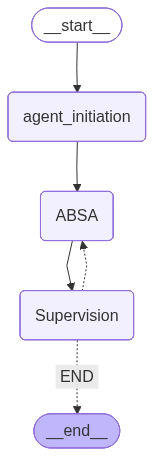

In [3]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [4]:
def run_absa_for_review(review_text: str, review_id: int):
    """Run your ABSA LangGraph pipeline on a single review."""
    try:
        # Create the initial state dynamically for each review
        state = ABSAState(
            review = review_text,
            review_id = review_id,

            absa_fields = [],
            absa_decision = "",
            absa_rationale = "",
            absa_counter = 0,
        )

        # Run the graph
        result = app.invoke(state, {"recursion_limit": 100, "thread_id":review_id})

        # Extract only the relevant outputs
        return {
            "absa_fields": result.get("absa_fields", []),
            "absa_decision": result.get("absa_decision", ""),
        }

    except Exception as e:
        print(f"Error for review: {review_text[:25]}... -> {e}")
        return {
            "absa_fields": [],
            "absa_decision": "",
        }

In [5]:
df3 = pd.read_excel('../data/1000_annotated_sample_final.xlsx')
df3 = df3.drop(columns=(['Unnamed: 0', 'flag']))
df3['ind'] = df3.index.astype(int)
df3.shape

(1000, 13)

In [8]:
# res3 = run_absa_for_review(review_text=df3.loc[1, 'text'], review_id=int(df3.loc[1, 'ind']))

In [12]:
# res3

In [ ]:
df3["absa_results"] = df3.progress_apply(func= lambda row: run_absa_for_review(review_text=row["text"], review_id=row["ind"]),
                                        axis=1)

df3["sentiments"] = df3["absa_results"].apply(lambda x: x["absa_fields"])

In [ ]:
df3.to_excel('1000_annotated_sample_final_graph_3_v2.xlsx')

# Validation results

In [2]:
import spacy
import numpy as np
import pandas as pd
import seaborn as sns
import json
import ast
import re

In [3]:
df1 = pd.read_excel("../results/1000_annotated_sample_final_graph_1_v2.xlsx")
df2 = pd.read_excel("../results/1000_annotated_sample_final_graph_2_v2.xlsx")
df3 = pd.read_excel("../results/1000_annotated_sample_final_graph_3_v2.xlsx")


df1 = df1.add_suffix('_graph_1')
df2 = df2.add_suffix('_graph_2')
df3 = df3.add_suffix('_graph_3')


merged_df = pd.concat([df1, df2, df3], axis=1)
merged_df.head(2)

,Unnamed: 0_graph_1,place_id_graph_1,author_graph_1,rating_graph_1,date_graph_1,text_graph_1,place_name_graph_1,index_graph_1,date_parsed_graph_1,ABSA_manual_graph_1,atepc_json_graph_1,len_manual_graph_1,len_atepc_graph_1,ind_graph_1,absa_results_graph_1,sentiments_graph_1,Unnamed: 0_graph_2,place_id_graph_2,author_graph_2,rating_graph_2,date_graph_2,text_graph_2,place_name_graph_2,index_graph_2,date_parsed_graph_2,...,atepc_json_graph_2,len_manual_graph_2,len_atepc_graph_2,proccesed_res_graph_2,len_res_graph_2,len_diff_graph_2,ind_graph_2,absa_results_graph_2,sentiments_graph_2,Unnamed: 0_graph_3,place_id_graph_3,author_graph_3,rating_graph_3,date_graph_3,text_graph_3,place_name_graph_3,index_graph_3,date_parsed_graph_3,ABSA_manual_graph_3,atepc_json_graph_3,len_manual_graph_3,len_atepc_graph_3,ind_graph_3,absa_results_graph_3,sentiments_graph_3
0,0,ChIJs_LE...,Edward R...,1,3 years ago,Utterly ...,Crave Ca...,2720,2022-10-11,"{""overal...",{'senten...,1,1,0,{'aspect...,[{'aspec...,0,ChIJs_LE...,Edward R...,1,3 years ago,Utterly ...,Crave Ca...,",",2022-10-11,...,{'senten...,2,1,[{'aspec...,2,0,0,{'aspect...,[{'aspec...,0,ChIJs_LE...,Edward R...,1,3 years ago,Utterly ...,Crave Ca...,2720,2022-10-11,"{""overal...",{'senten...,1,1,0,{'absa_f...,[{'aspec...
1,1,ChIJ7yq6...,James Ma...,1,Edited 5...,Very ver...,Australi...,29442,2020-10-11,"{""overal...",{'senten...,1,1,1,{'aspect...,[{'aspec...,1,ChIJ7yq6...,James Ma...,1,Edited 5...,Very ver...,Australi...,29442,2020-10-11,...,{'senten...,1,1,[{'aspec...,2,-1,1,{'aspect...,[{'aspec...,1,ChIJ7yq6...,James Ma...,1,Edited 5...,Very ver...,Australi...,29442,2020-10-11,"{""overal...",{'senten...,1,1,1,{'absa_f...,[{'aspec...


In [4]:
nlp = spacy.load('en_core_web_lg')

def cosine_similarity(word_a: str, word_b: str) -> float:
    vector_a = nlp(word_a).vector
    vector_b = nlp(word_b).vector
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    return dot_product / (magnitude_a * magnitude_b)

def parse_col1(x):
    if not isinstance(x, str):
        return []
    try:
        return json.loads(x).get("aspects", [])
    except Exception:
        return []

def parse_col2(x):
    if not x:
        return []
    try:
        return ast.literal_eval(x)
    except Exception:
        return x 

def normalize(a):
    return a.lower().strip()

def compare_aspects(aspects1, aspects2):
    matches = 0
    l = []
    try:
        for a1 in aspects1:
            asp1 = normalize(a1.get("aspect", ""))
            sent1 = normalize(a1.get("sentiment", ""))

            for a2 in aspects2:
                asp2 = normalize(a2.get("aspect", ""))
                sent2 = normalize(a2.get("sentiment", ""))
                
                if cosine_similarity(asp1, asp2) >= 0.70 and (asp2 not in l): 
                    if sent1 == sent2:
                        matches += 1
                        break
    except Exception:
        return None
    return matches


def node_nlp_extract_pairs(nlp_text: str) -> str:
    """Extract aspects & sentiments from the NLP-annotated fields."""
    raw = nlp_text
    if not raw:
        aspects = []
        sentiments = []

    try:
        parsed = ast.literal_eval(raw)
    except Exception as e:
        aspects = []
        sentiments = []

    aspects = [str(a).strip() for a in parsed.get("aspect", []) or []]
    labels  = [str(s).strip().lower() for s in parsed.get("sentiment", []) or []]

    allowed = {"positive", "negative", "neutral"}
    items = []
    for a, lab in zip(aspects, labels):
        lab = lab if lab in allowed else "neutral"
        items.append({"aspect": a, "opinion": "", "sentiment": lab})
  
    return items

In [5]:
merged_df.columns

Index(['Unnamed: 0_graph_1', 'place_id_graph_1', 'author_graph_1',
       'rating_graph_1', 'date_graph_1', 'text_graph_1', 'place_name_graph_1',
       'index_graph_1', 'date_parsed_graph_1', 'ABSA_manual_graph_1',
       'atepc_json_graph_1', 'len_manual_graph_1', 'len_atepc_graph_1',
       'ind_graph_1', 'absa_results_graph_1', 'sentiments_graph_1',
       'Unnamed: 0_graph_2', 'place_id_graph_2', 'author_graph_2',
       'rating_graph_2', 'date_graph_2', 'text_graph_2', 'place_name_graph_2',
       'index_graph_2', 'date_parsed_graph_2', 'ABSA_manual_graph_2',
       'atepc_json_graph_2', 'len_manual_graph_2', 'len_atepc_graph_2',
       'proccesed_res_graph_2', 'len_res_graph_2', 'len_diff_graph_2',
       'ind_graph_2', 'absa_results_graph_2', 'sentiments_graph_2',
       'Unnamed: 0_graph_3', 'place_id_graph_3', 'author_graph_3',
       'rating_graph_3', 'date_graph_3', 'text_graph_3', 'place_name_graph_3',
       'index_graph_3', 'date_parsed_graph_3', 'ABSA_manual_graph_3',
 

In [6]:
merged_df["aspects_manual"] = merged_df["ABSA_manual_graph_1"].apply(parse_col1)
merged_df["atepc_json"] = merged_df["atepc_json_graph_1"].apply(node_nlp_extract_pairs)
merged_df["aspects_graph_1"] = merged_df["sentiments_graph_1"].apply(parse_col2)
merged_df["aspects_graph_2"] = merged_df["sentiments_graph_2"].apply(parse_col2)
merged_df["aspects_graph_3"] = merged_df["sentiments_graph_3"].apply(parse_col2)

In [53]:
absa_cols = [
    "aspects_manual",
    "atepc_json",
    "aspects_graph_1",
    "aspects_graph_2",
    "aspects_graph_3",
]

n = len(absa_cols)
match_matrix = np.zeros((n, n), dtype=int)

for i in range(n):
    for j in range(n):
        # j = 0
        # if i <= j: 
            print(i, ', ', j)
            match_matrix[i, j] = merged_df.apply(
                                                lambda row: compare_aspects(row[absa_cols[i]], row[absa_cols[j]]),
                                                axis=1
                                        ).sum()

0 ,  0


C:\Users\asus\AppData\Local\Temp\ipykernel_20120\4251017876.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return dot_product / (magnitude_a * magnitude_b)


0 ,  1
0 ,  2
0 ,  3
0 ,  4
1 ,  0
1 ,  1
1 ,  2
1 ,  3
1 ,  4
2 ,  0
2 ,  1
2 ,  2
2 ,  3
2 ,  4
3 ,  0
3 ,  1
3 ,  2
3 ,  3
3 ,  4
4 ,  0
4 ,  1
4 ,  2
4 ,  3
4 ,  4


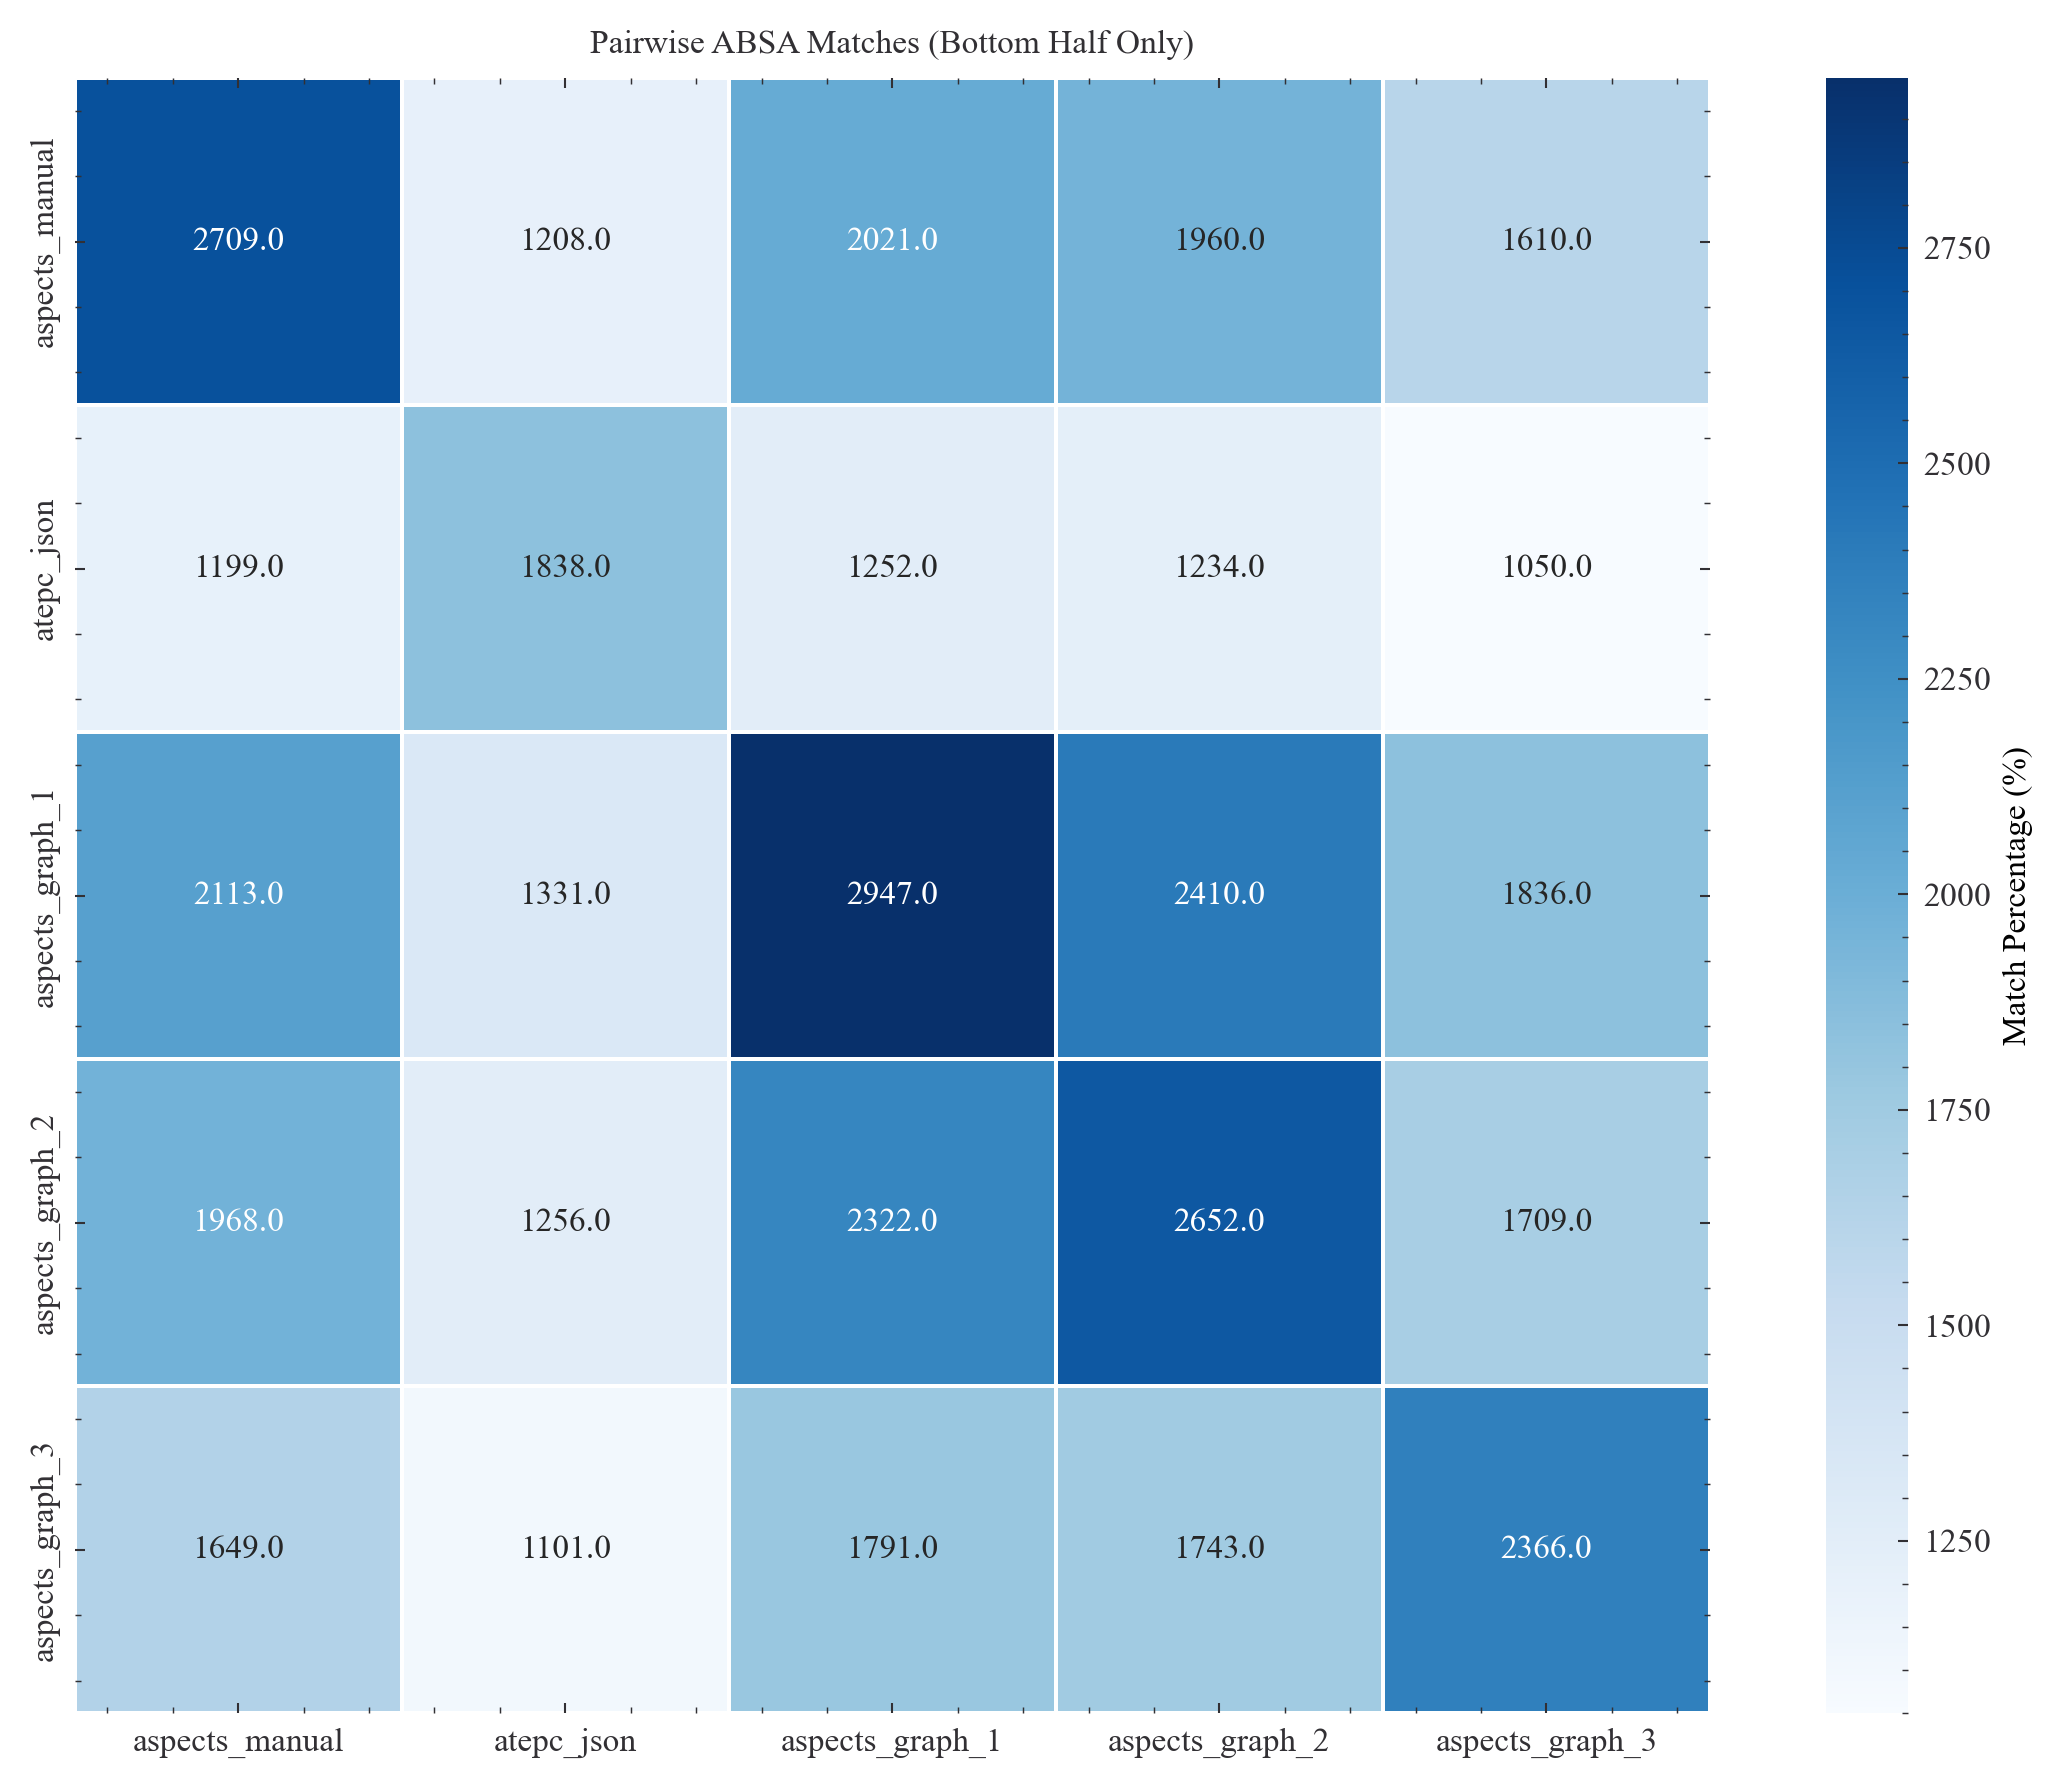

In [54]:
# mask = np.triu(np.ones_like(match_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    match_matrix,
    annot=True,
    fmt='.1f',        
    cmap='Blues',
    # mask=~mask,        
    xticklabels=absa_cols,
    yticklabels=absa_cols,
    square=True,       
    linewidths=0.5,
    cbar_kws={"label": "Match Percentage (%)"}
)

plt.title("Pairwise ABSA Matches (Bottom Half Only)")
plt.tight_layout()
plt.show()


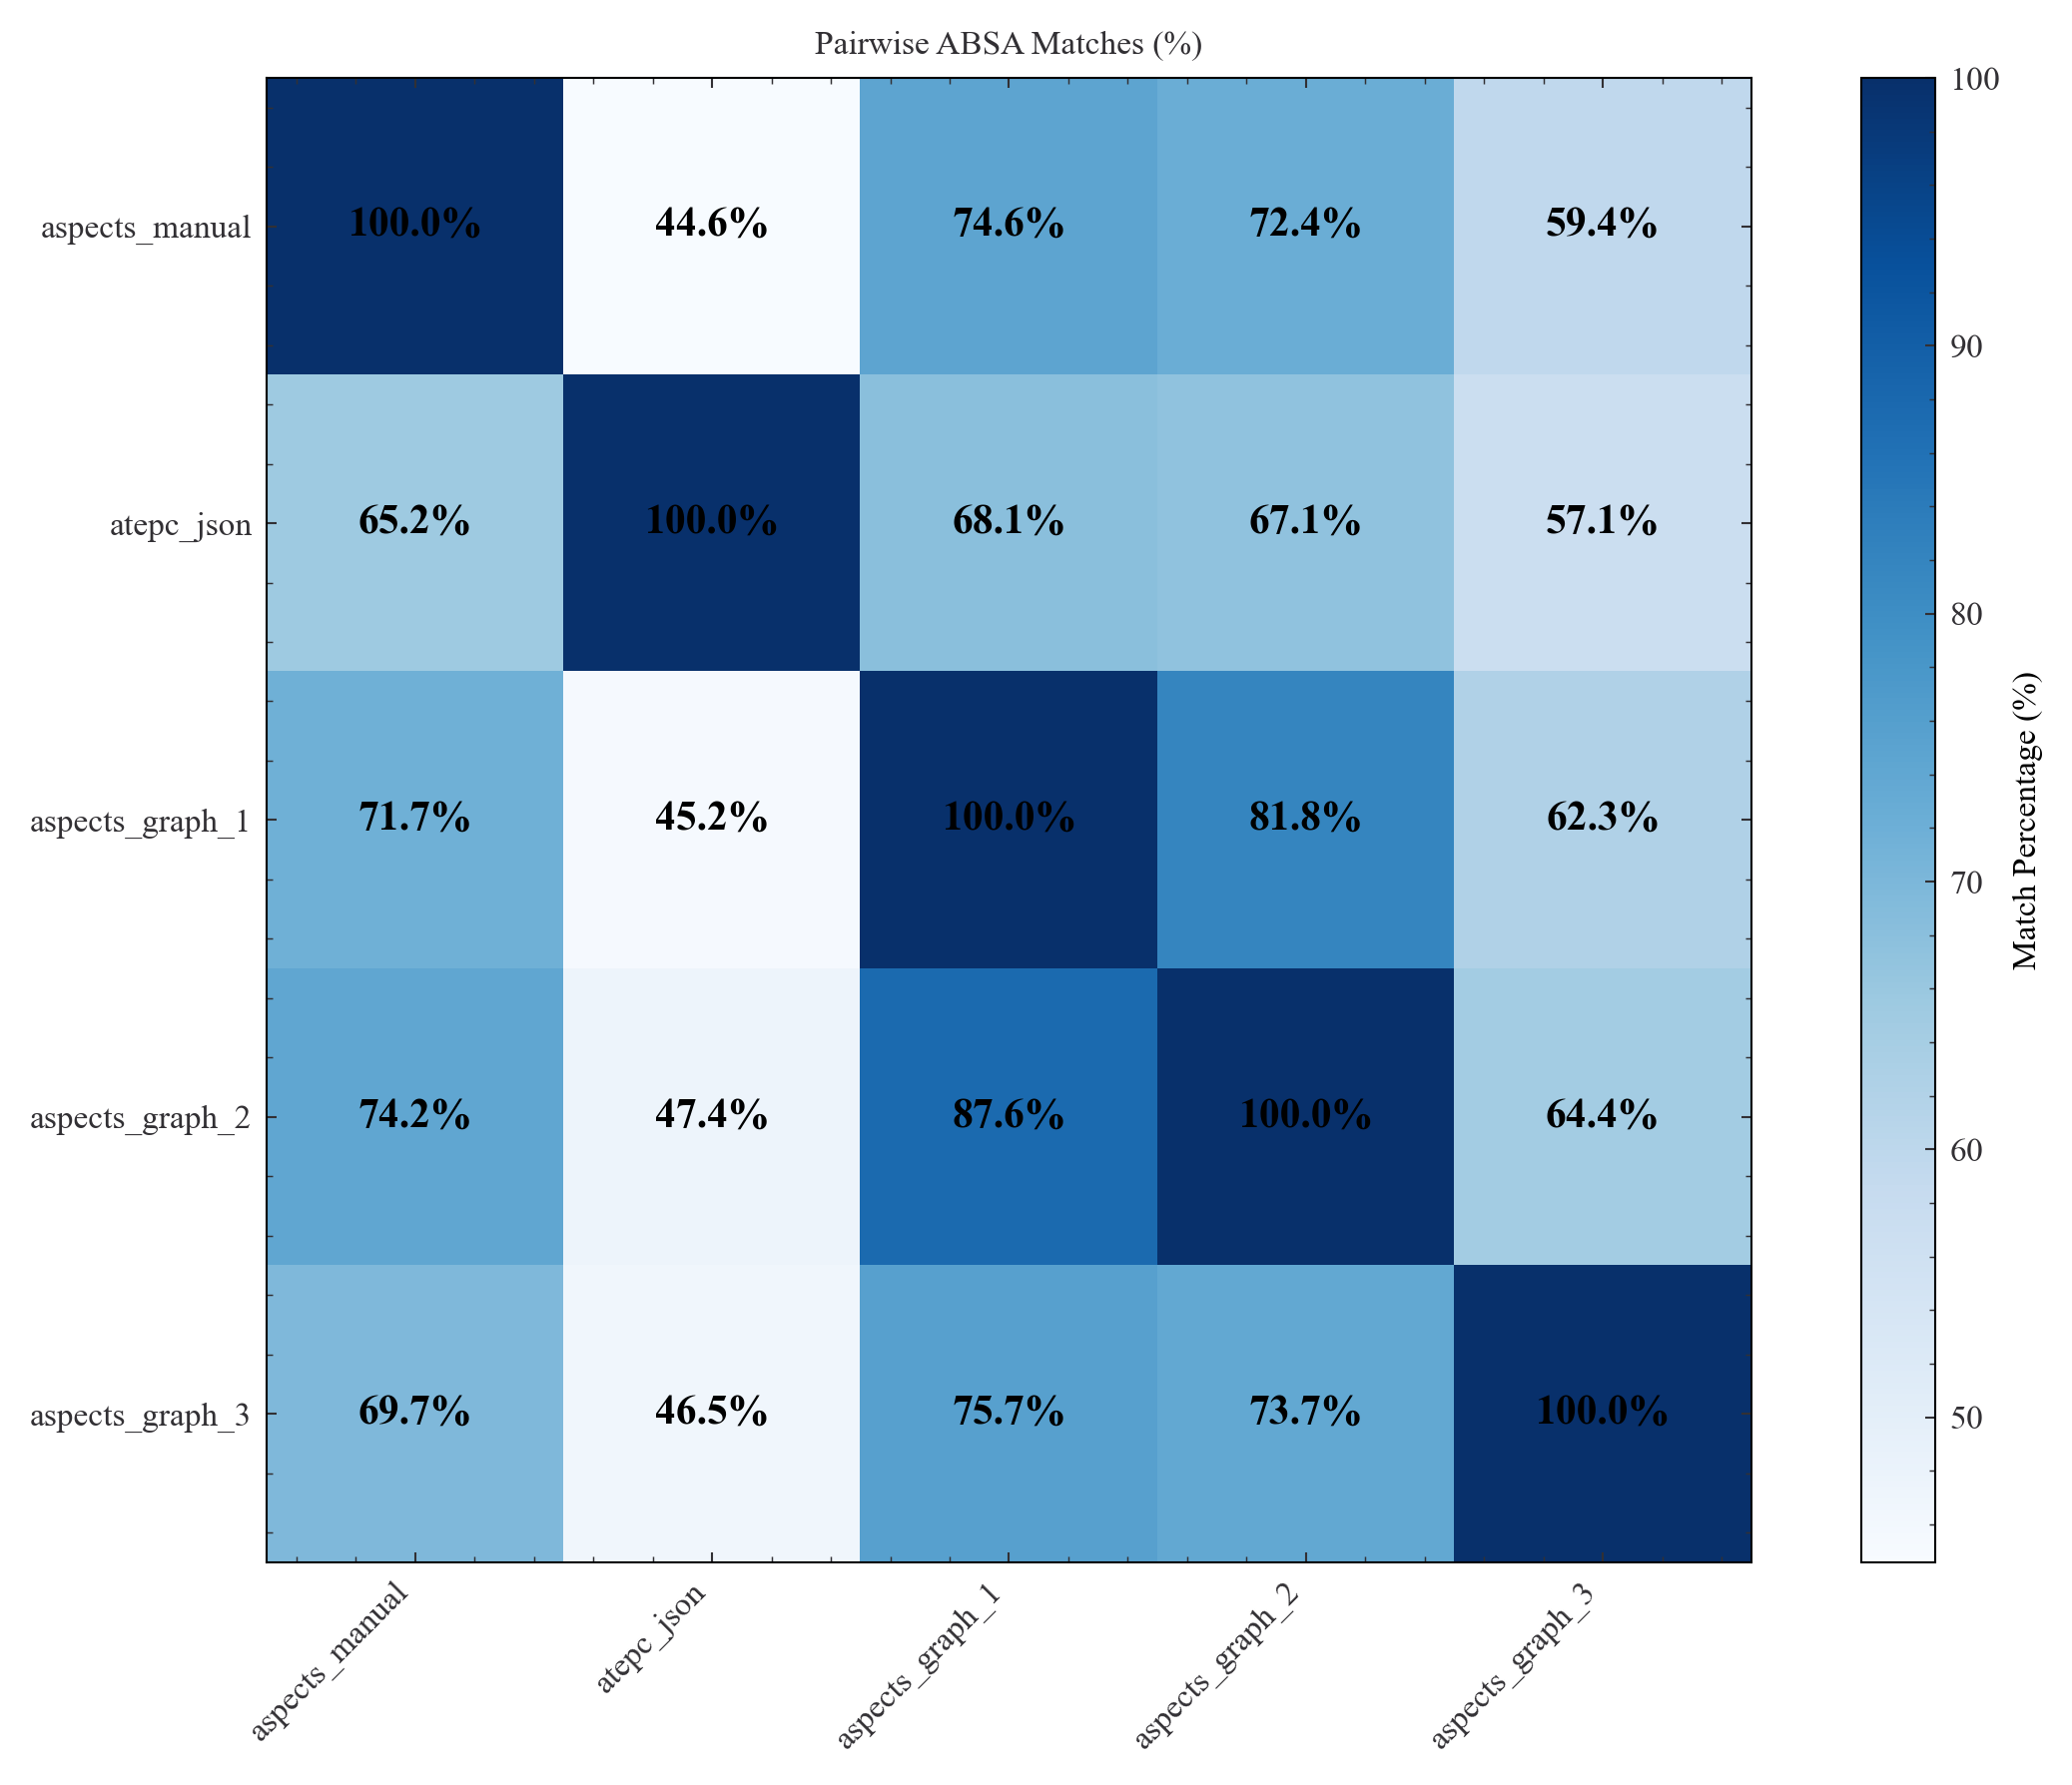

In [59]:
n = match_matrix.shape[0]
percent_matrix = np.zeros(match_matrix.shape)
for i in range(n):
    total= match_matrix[i, i]
    for j in range(n):
        percent_matrix[i, j] = (match_matrix[i, j] / total) * 100 


plt.figure(figsize=(8, 6))
plt.imshow(percent_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Match Percentage (%)')

for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{percent_matrix[i, j]:.1f}%",  # one decimal place
                 ha='center', va='center', color='black', fontsize=10, fontweight='bold')

plt.xticks(range(n), absa_cols, rotation=45, ha='right')
plt.yticks(range(n), absa_cols)
plt.title("Pairwise ABSA Matches (%)")
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from collections import defaultdict
from math import isnan

In [57]:
def norm(s: str) -> str:
    return str(s).strip().lower()

def cosine_similarity(word_a: str, word_b: str) -> float:
    vector_a = nlp(word_a).vector
    vector_b = nlp(word_b).vector
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0
    return dot_product / (magnitude_a * magnitude_b)


aspect_tp = 0
aspect_fp = 0
aspect_fn = 0

y_true = []  
y_pred = []

SIM_THRESHOLD = 0.7

def find_best_match(gold_aspect, pred_aspects):
    max_sim = -1
    best_match = None
    for pred in pred_aspects:
        sim = cosine_similarity(gold_aspect, pred)
        if sim > max_sim:
            max_sim = sim
            best_match = pred
    return best_match, max_sim

In [58]:
for _, row in merged_df.iterrows():
    gold_list = row["aspects_manual"] or []
    pred_list = row["aspects_graph_1"] or []

    gold_dict = {str(d.get("aspect","")).lower(): str(d.get("sentiment","")).lower()
                 for d in gold_list}
    
    pred_dict = {str(d.get("aspect","")).lower(): str(d.get("sentiment","")).lower()
                 for d in pred_list}

    gold_aspects = set(gold_dict.keys())
    pred_aspects = set(pred_dict.keys())
    
    used_pred = set()
    tp_aspects = set()
    fp_aspects = set()
    fn_aspects = set()

    # Attempt fuzzy matching (gold -> best pred)
    for gold_a in gold_aspects:
        best_pred, sim = find_best_match(gold_a, pred_aspects - used_pred)
        if best_pred is not None and sim >= SIM_THRESHOLD:
            tp_aspects.add((gold_a, best_pred))
            used_pred.add(best_pred)
        else:
            fn_aspects.add(gold_a)

    # Remaining predictions are FPs
    for pred_a in pred_aspects:
        if pred_a not in used_pred:
            fp_aspects.add(pred_a)

    aspect_tp += len(tp_aspects)
    aspect_fp += len(fp_aspects)
    aspect_fn += len(fn_aspects)

    # Sentiment evaluation on matched items
    for gold_a, matched_pred_a in tp_aspects:
        y_true.append(gold_dict[gold_a])
        y_pred.append(pred_dict[matched_pred_a])

In [59]:
precision_aspect = aspect_tp / (aspect_tp + aspect_fp) if (aspect_tp + aspect_fp) > 0 else 0.0
recall_aspect = aspect_tp / (aspect_tp + aspect_fn) if (aspect_tp + aspect_fn) > 0 else 0.0
f1_aspect = (
    2 * precision_aspect * recall_aspect / (precision_aspect + recall_aspect)
    if (precision_aspect + recall_aspect) > 0
    else 0.0
)

print("Aspect extraction using cosine similarity")
print(f"TP: {aspect_tp}  FP: {aspect_fp}  FN: {aspect_fn}")
print(f"Precision: {precision_aspect:.3f}")
print(f"Recall:    {recall_aspect:.3f}")
print(f"F1:        {f1_aspect:.3f}")

Aspect extraction using cosine similarity
TP: 2065  FP: 745  FN: 645
Precision: 0.735
Recall:    0.762
F1:        0.748


In [60]:
labels = ["positive", "negative", "neutral"]
cm = pd.crosstab(
    pd.Categorical(y_true, categories=labels),
    pd.Categorical(y_pred, categories=labels),
    rownames=["gold"],
    colnames=["pred"],
    dropna=False
)

print("\nSentiment confusion matrix (gold rows, pred columns)")
print(cm)


Sentiment confusion matrix (gold rows, pred columns)
pred      positive  negative  neutral
gold                                 
positive      1070        13       31
negative         5       854       20
neutral          5        14       53


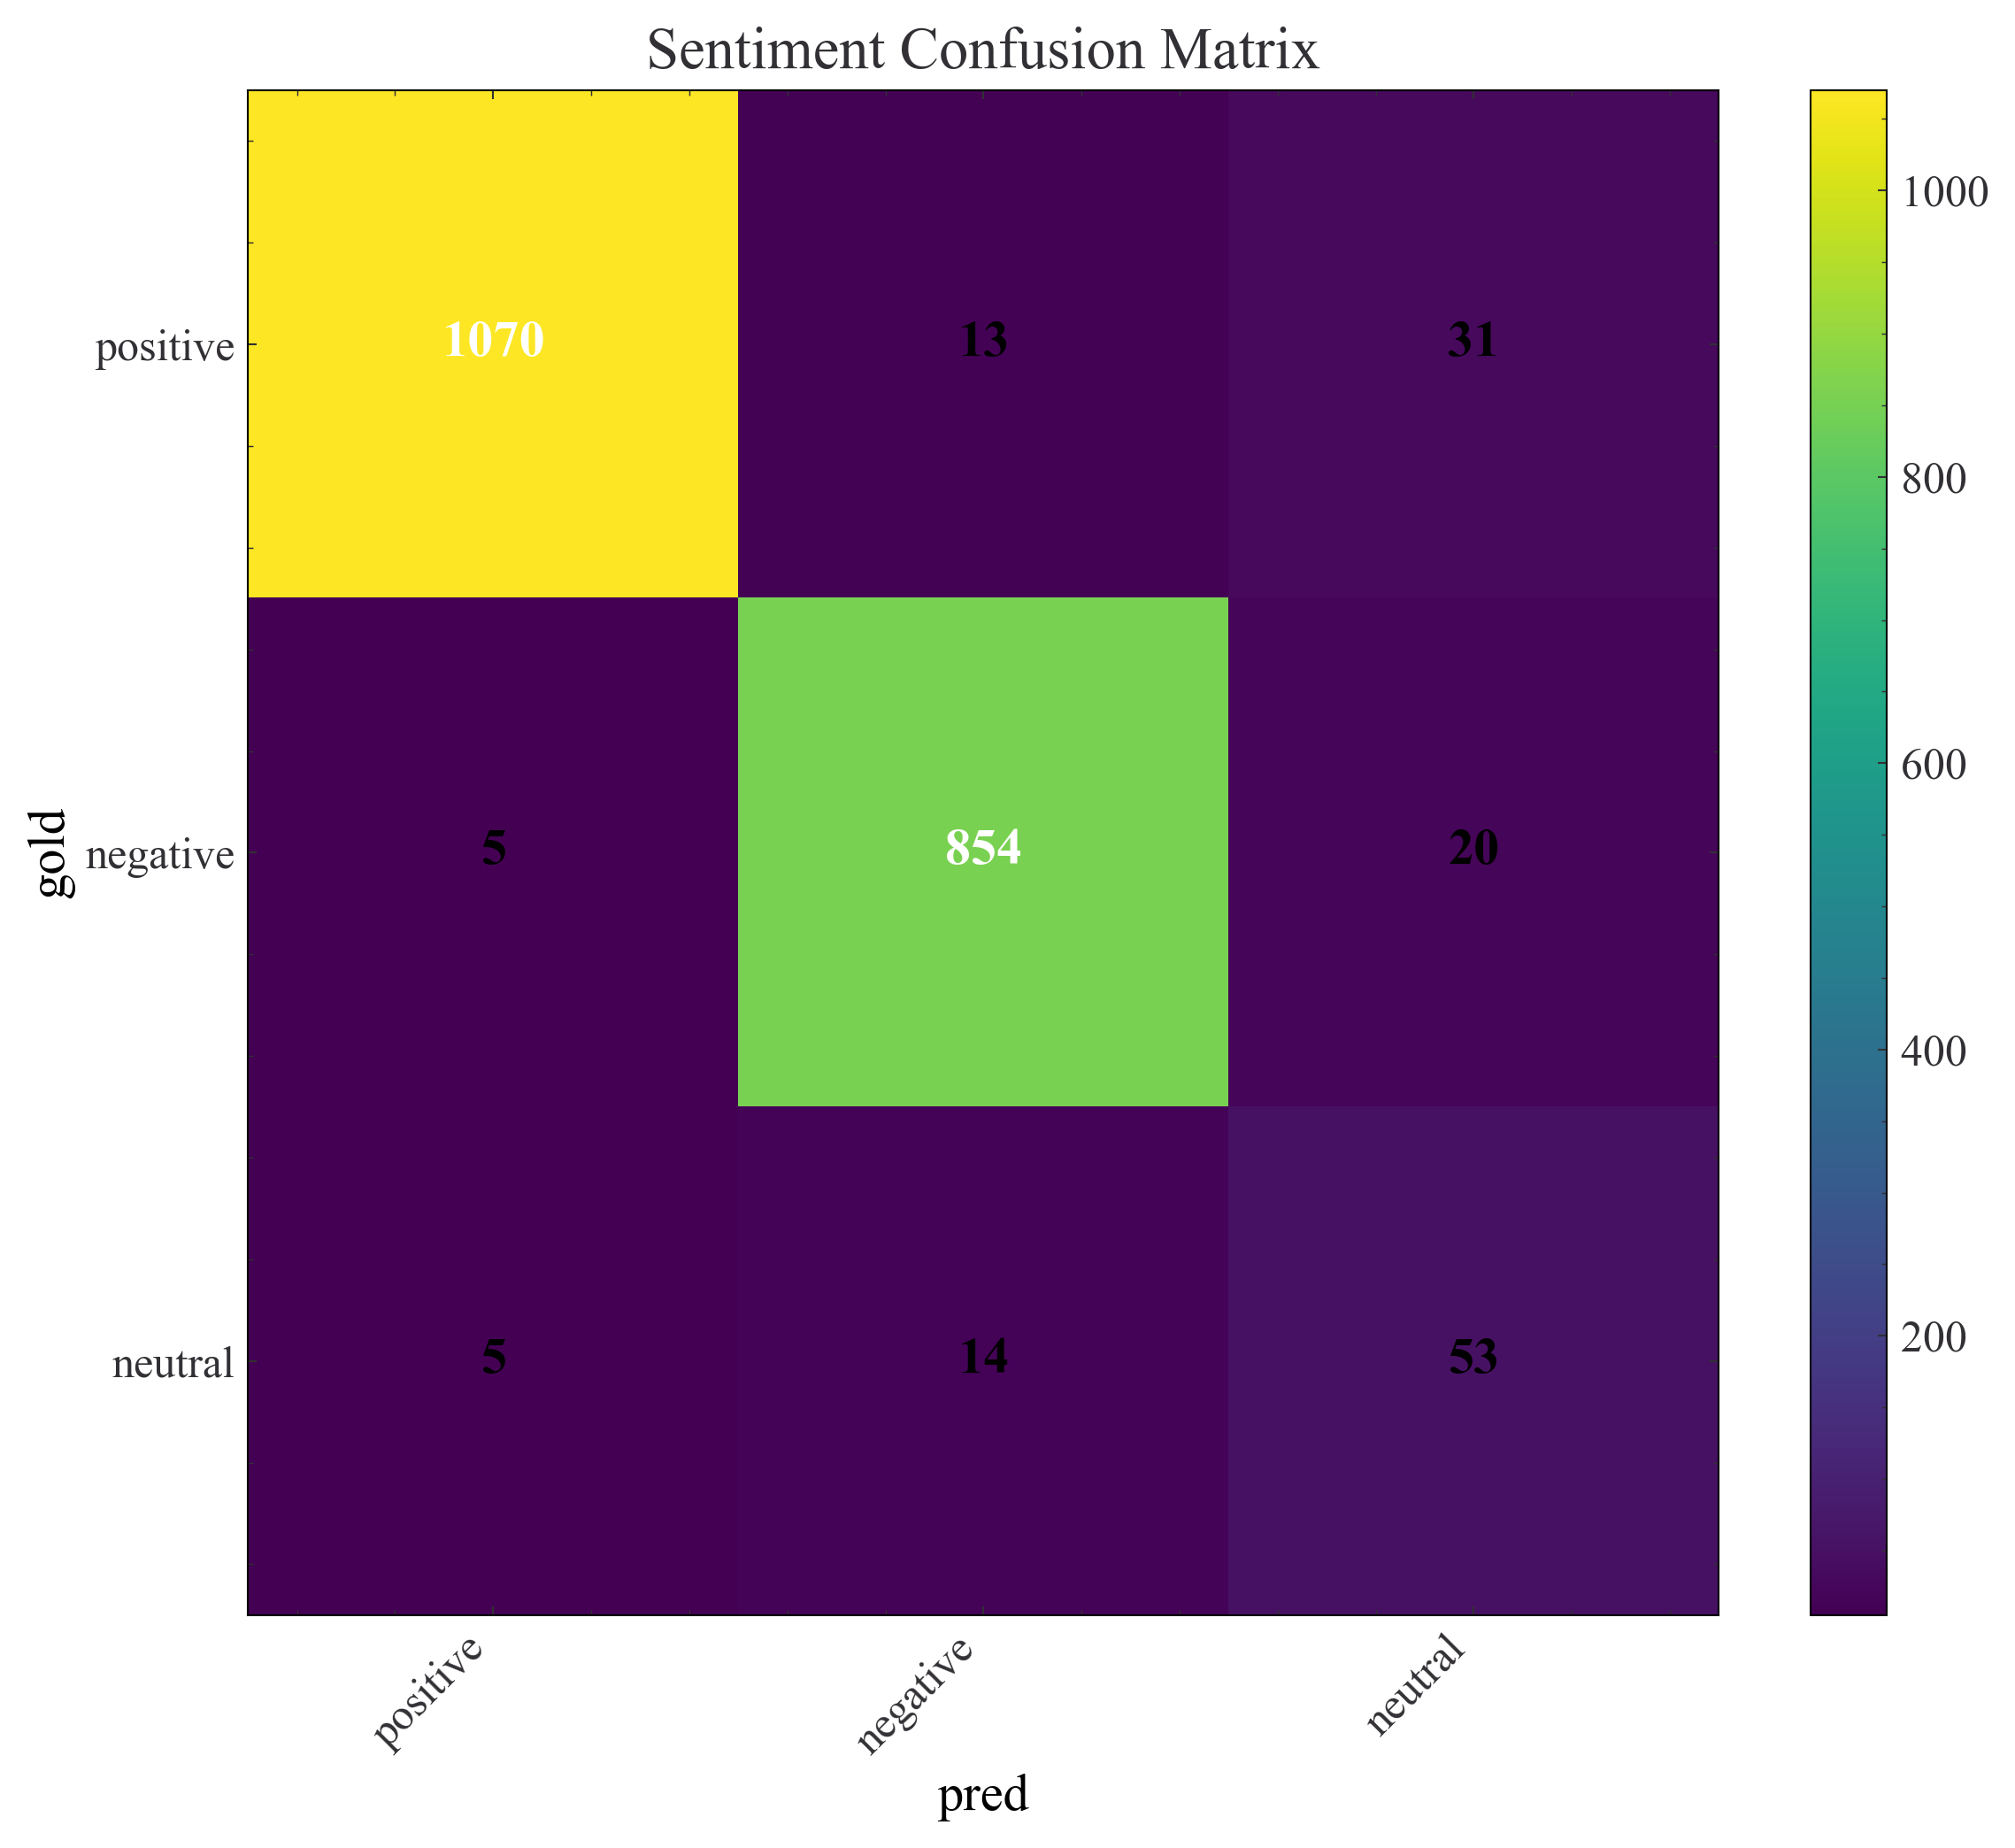

In [61]:
cm_values = cm.values

fig, ax = plt.subplots(figsize=(8,7))

# Heatmap with smoother color scaling
im = ax.imshow(cm_values, aspect="auto")

# Ticks and labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=12)

# Annotate each cell with value and auto-contrast text color
max_val = cm_values.max()
for i in range(len(labels)):
    for j in range(len(labels)):
        val = cm_values[i, j]
        color = "white" if val > max_val * 0.5 else "black"
        ax.text(j, i, val, ha="center", va="center", fontsize=14, color=color, fontweight="bold")

# Labels and title
ax.set_xlabel("pred", fontsize=14)
ax.set_ylabel("gold", fontsize=14)
ax.set_title("Sentiment Confusion Matrix", fontsize=16)

# Add colorbar
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

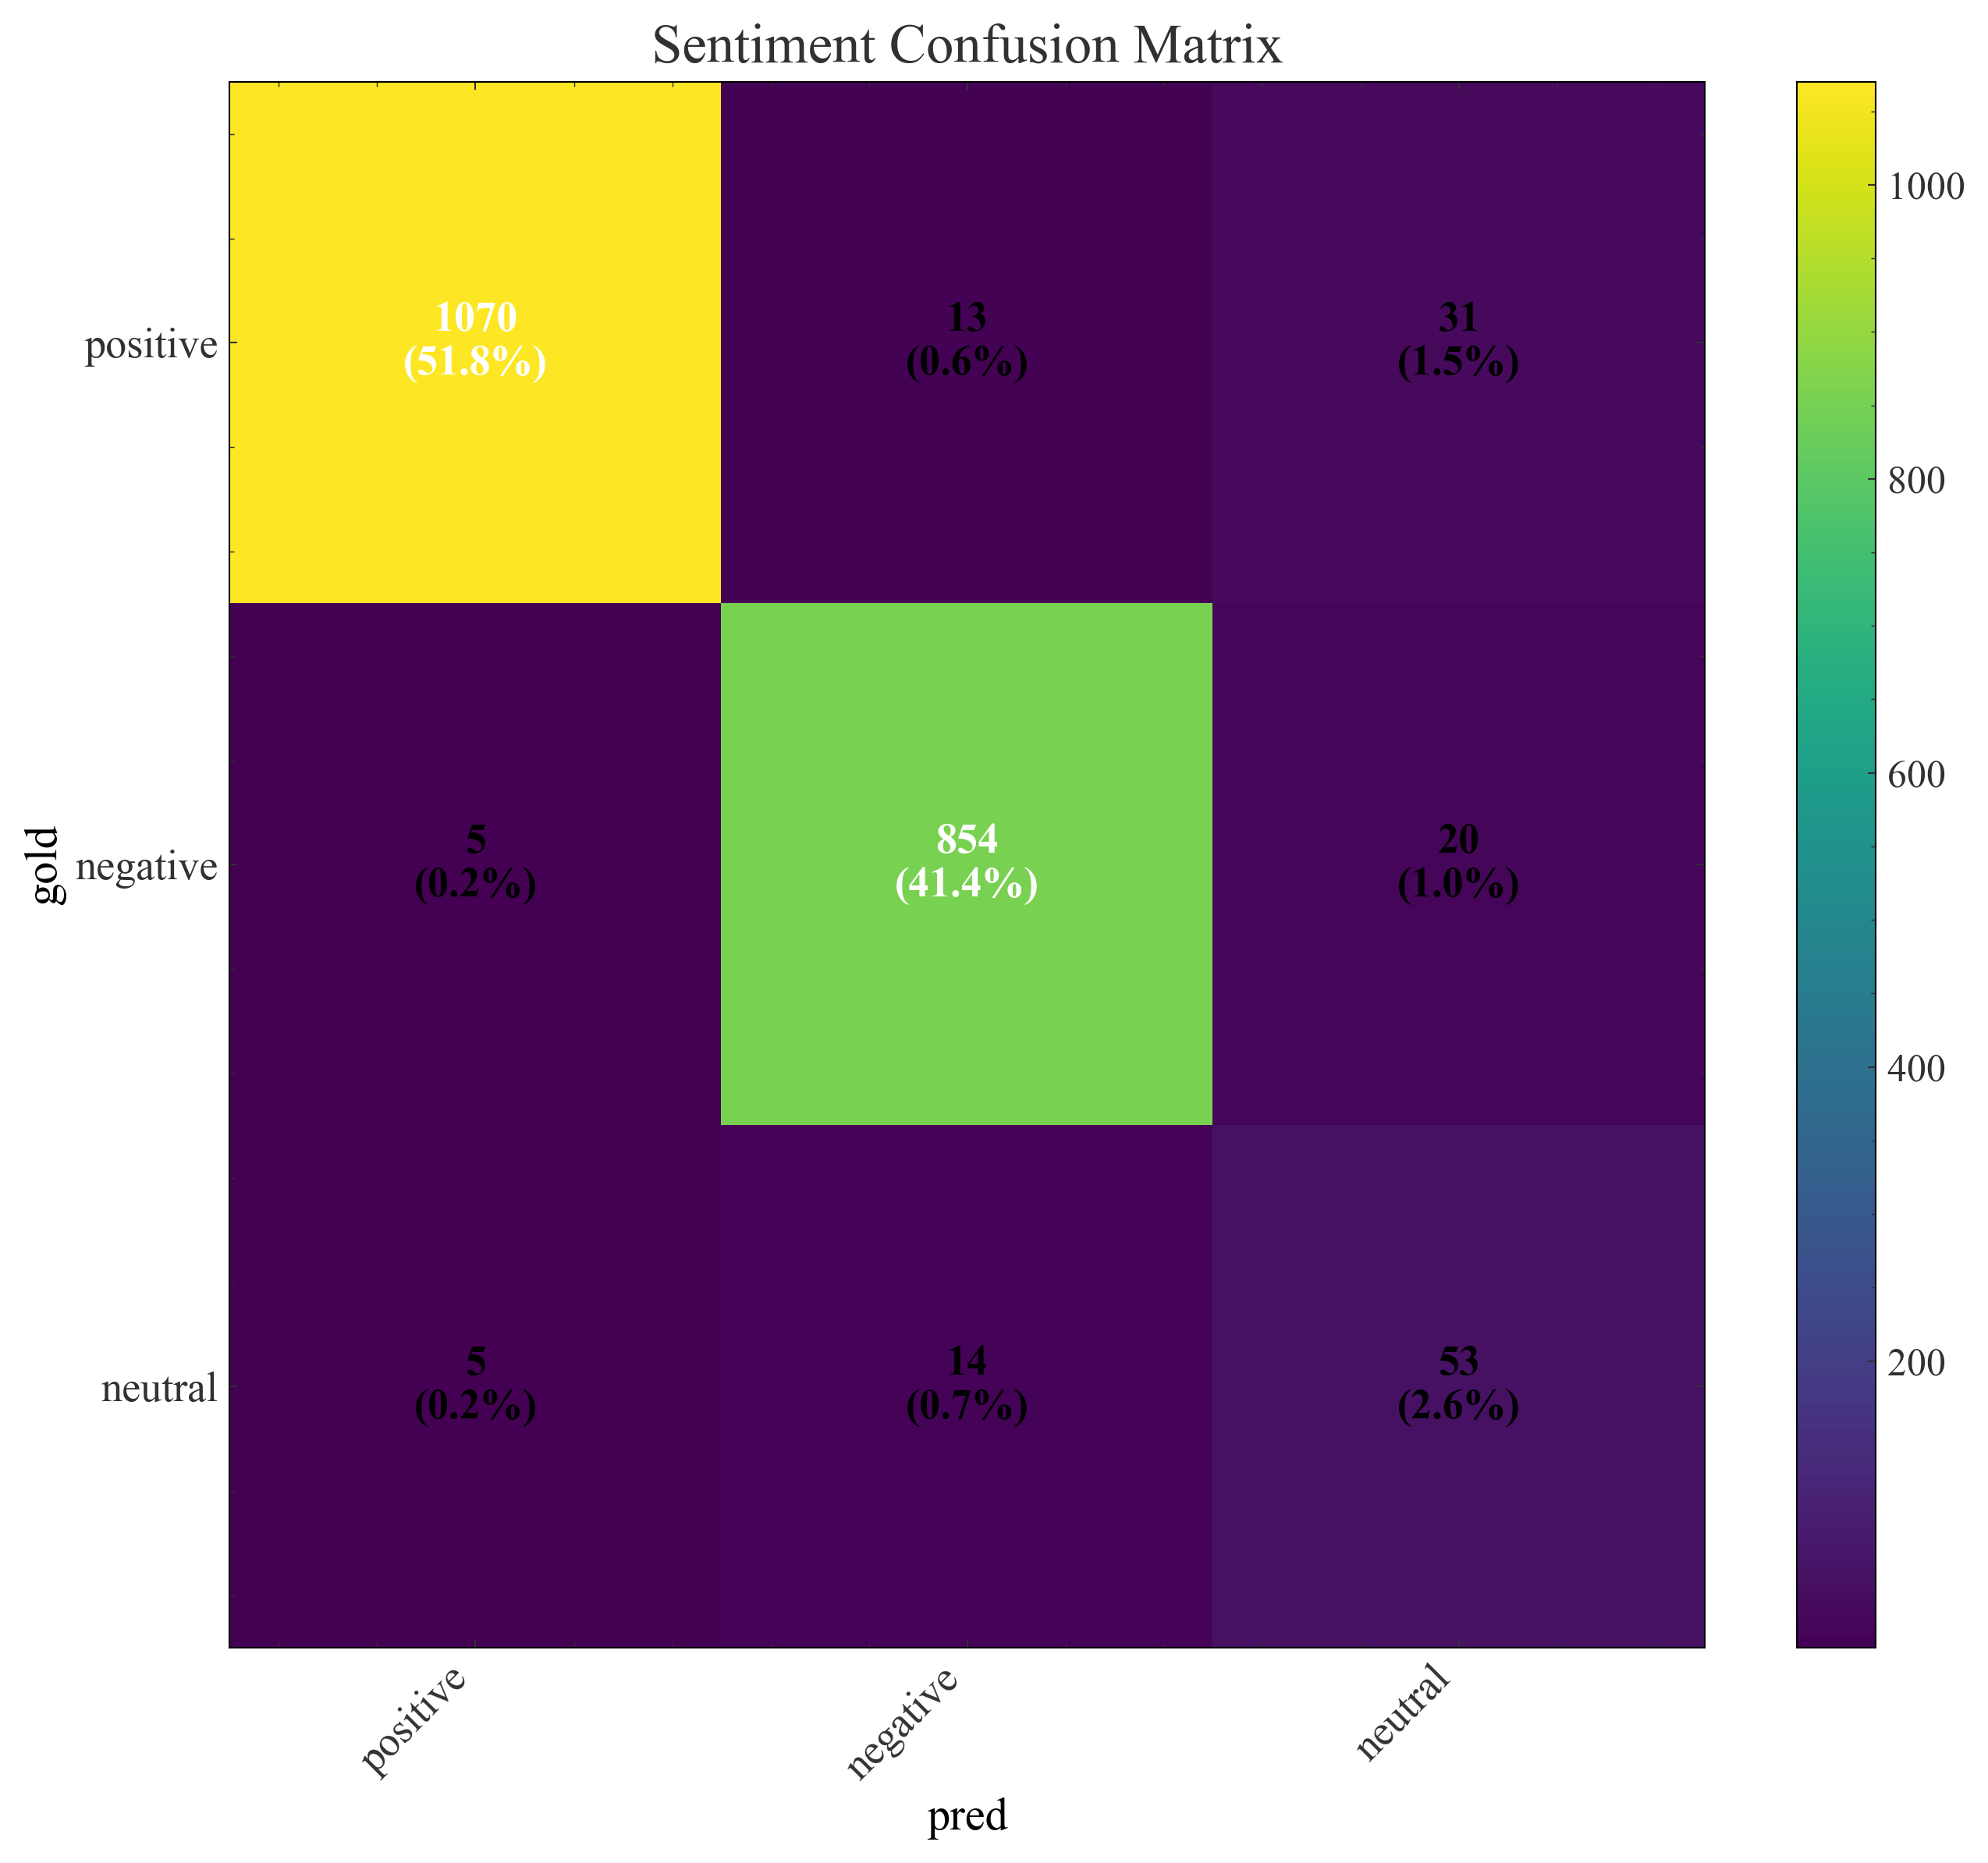

In [62]:
fig, ax = plt.subplots(figsize=(9,8))

# Draw heatmap
im = ax.imshow(cm_values, aspect="auto")

# Set tick labels
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=13)
ax.set_yticklabels(labels, fontsize=13)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Calculate total percentages
total = cm_values.sum()
percent_matrix = (cm_values / total) * 100 if total > 0 else np.zeros_like(cm_values, dtype=float)

# Annotate each cell
max_val = cm_values.max()
for i in range(len(labels)):
    for j in range(len(labels)):
        count = cm_values[i, j]
        pct = percent_matrix[i, j]
        color = "white" if count > max_val * 0.5 else "black"
        text = f"{count}\n({pct:.1f}%)"
        ax.text(j, i, text, ha="center", va="center", fontsize=13, color=color, fontweight="bold")

# Axis titles
ax.set_xlabel("pred", fontsize=14)
ax.set_ylabel("gold", fontsize=14)
ax.set_title("Sentiment Confusion Matrix", fontsize=17)

# Colorbar
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()